# Gradient Descent

Gradient Descent is one of the most fundamental optimization algorithms in machine learning. It is used to **minimize a cost/loss function** by iteratively moving in the direction of steepest descent as defined by the negative of the gradient.

In this notebook, we will:
1. Build intuition for what gradient descent does
2. Derive the math behind it
3. Implement it from scratch in Python
4. Visualize the optimization process
5. Explore variants: Batch, Stochastic, and Mini-Batch
6. Understand learning rate and convergence

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")

---
## 1. The Intuition — Rolling Downhill

Imagine you are standing on a hilly landscape **blindfolded**. Your goal is to reach the lowest point (the valley). What would you do?

1. **Feel the slope** beneath your feet (compute the gradient)
2. **Take a step downhill** — in the direction where the ground drops the steepest (move opposite to the gradient)
3. **Repeat** until you feel flat ground (gradient ≈ 0, you've reached a minimum)

This is exactly what gradient descent does — but in the space of model parameters.

### Let's visualize this with a simple 1D function

Consider the function $ f(x) = x^2 $. Its minimum is at $ x = 0 $.

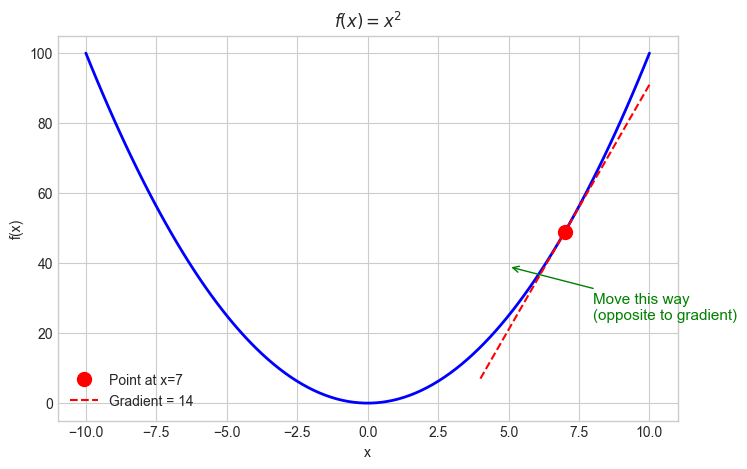

In [2]:
# Define the function and its derivative
def f(x):
    return x**2


def df(x):
    """Derivative of f(x) = x^2 is f'(x) = 2x"""
    return 2 * x


# Plot the function
x = np.linspace(-10, 10, 100)
plt.figure(figsize=(8, 5))
plt.plot(x, f(x), "b-", linewidth=2)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("$f(x) = x^2$")

# Show the gradient at a point
x0 = 7
plt.plot(x0, f(x0), "ro", markersize=10, label=f"Point at x={x0}")
# Draw tangent line
tangent_x = np.linspace(x0 - 3, x0 + 3, 50)
tangent_y = f(x0) + df(x0) * (tangent_x - x0)
plt.plot(tangent_x, tangent_y, "r--", linewidth=1.5, label=f"Gradient = {df(x0)}")
plt.annotate(
    "Move this way\n(opposite to gradient)",
    xy=(x0 - 2, f(x0) - 10),
    fontsize=11,
    color="green",
    arrowprops=dict(arrowstyle="->", color="green"),
    xytext=(x0 + 1, f(x0) - 25),
)
plt.legend()
plt.show()

The gradient (slope) at $ x=7 $ is $ f'(7) = 14 $ (positive → function is increasing). To minimize, we move in the **negative gradient direction** (to the left).

---
## 2. The Mathematics

### The Update Rule

Gradient descent updates a parameter $ \theta $ using:

$$\theta_{\text{new}} = \theta_{\text{old}} - \alpha \cdot \nabla J(\theta)$$

Where:
- $ \theta $ = the parameter(s) we want to optimize
- $ \alpha $ = the **learning rate** (step size)
- $ \nabla J(\theta) $ = the **gradient** of the cost function with respect to $ \theta $

### Why the negative sign?

- The gradient points in the direction of **steepest ascent**
- We want to go **downhill** (minimize), so we move in the **opposite** direction
- Hence: $ \theta - \alpha \cdot \nabla J(\theta) $

### Applying to Linear Regression

In linear regression, we have:
- **Model**: $ \hat{y} = \theta_0 + \theta_1 x $ (for one feature)
- **Cost Function (MSE)**: 

$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$

where $ m $ is the number of training examples.

### Computing the Gradients

$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

$$\frac{\partial J}{\partial \theta_1} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) \cdot x^{(i)}$$

These partial derivatives tell us how much the cost changes when we nudge each parameter.

---
## 3. Gradient Descent on $ f(x) = x^2 $ (1D Example)

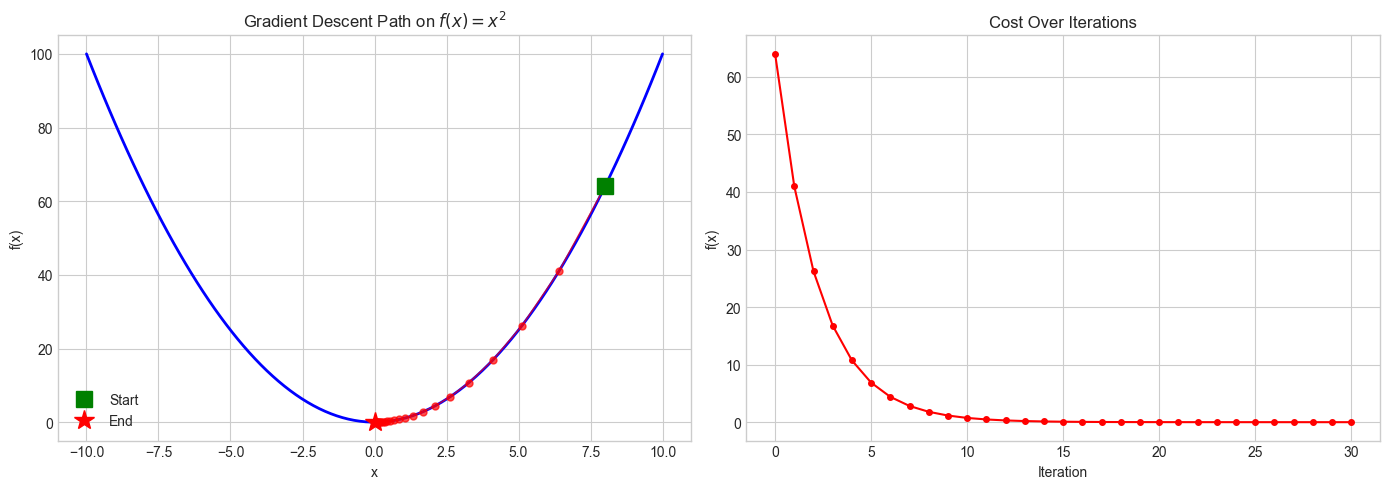

Started at x = 8.0000, f(x) = 64.0000
Ended at   x = 0.0099, f(x) = 0.0001


In [3]:
def gradient_descent_1d(starting_point, learning_rate, n_iterations):
    """Run gradient descent on f(x) = x^2"""
    x = starting_point
    history = [x]

    for i in range(n_iterations):
        gradient = df(x)  # compute gradient
        x = x - learning_rate * gradient  # update step
        history.append(x)

    return np.array(history)


# Run gradient descent
history = gradient_descent_1d(starting_point=8, learning_rate=0.1, n_iterations=30)

# Plot the optimization path
x_range = np.linspace(-10, 10, 100)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: path on the function
axes[0].plot(x_range, f(x_range), "b-", linewidth=2)
axes[0].plot(history, f(history), "ro-", markersize=5, linewidth=1, alpha=0.7)
axes[0].plot(history[0], f(history[0]), "gs", markersize=12, label="Start")
axes[0].plot(history[-1], f(history[-1]), "r*", markersize=15, label="End")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_title("Gradient Descent Path on $f(x) = x^2$")
axes[0].legend()

# Right: convergence of x and f(x)
axes[1].plot(range(len(history)), f(history), "r-o", markersize=4)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("f(x)")
axes[1].set_title("Cost Over Iterations")

plt.tight_layout()
plt.show()

print(f"Started at x = {history[0]:.4f}, f(x) = {f(history[0]):.4f}")
print(f"Ended at   x = {history[-1]:.4f}, f(x) = {f(history[-1]):.4f}")

Notice how:
- The steps are **large** at first (steep slope → big gradient)
- Steps get **smaller** as we approach the minimum (flat slope → small gradient)
- The cost decreases rapidly at first, then plateaus

---
## 4. The Learning Rate — The Most Important Hyperparameter

The learning rate $ \alpha $ controls the **size of each step**. Choosing it well is critical:

| Learning Rate | Behavior |
|---|---|
| Too small | Converges very slowly, wastes computation |
| Just right | Converges smoothly to the minimum |
| Too large | Overshoots, oscillates, may diverge |

Let's see this in action:

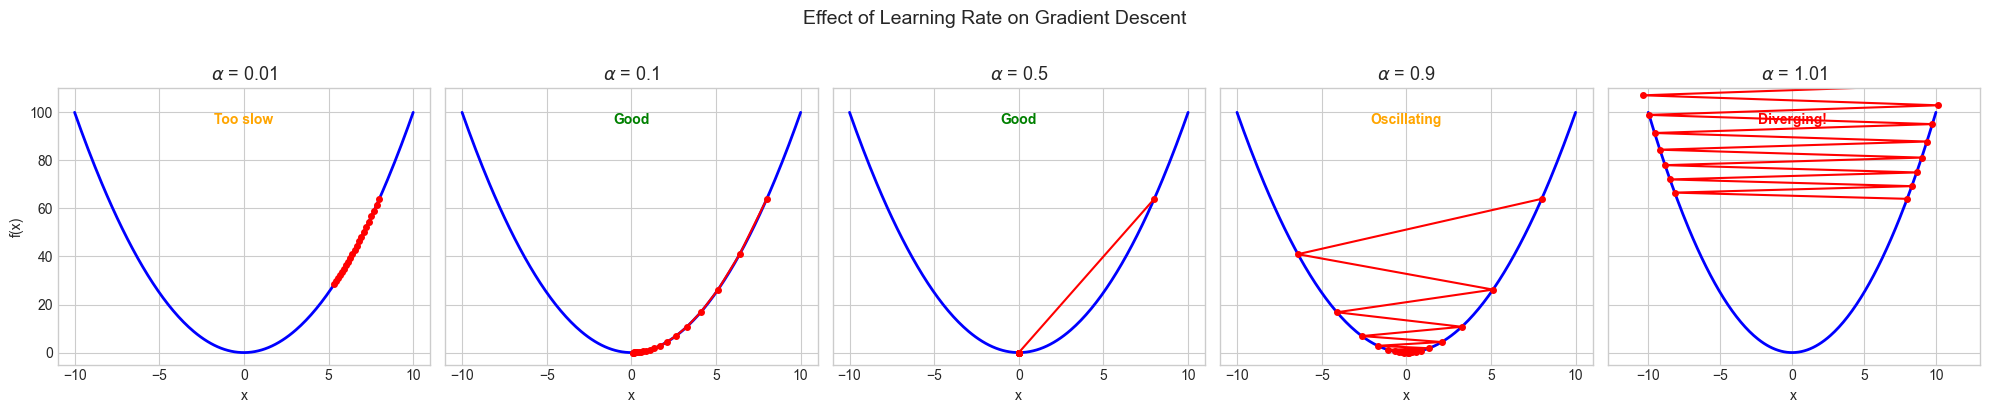

In [4]:
learning_rates = [0.01, 0.1, 0.5, 0.9, 1.01]
x_range = np.linspace(-10, 10, 200)

fig, axes = plt.subplots(1, len(learning_rates), figsize=(20, 4), sharey=True)

for i, lr in enumerate(learning_rates):
    history = gradient_descent_1d(starting_point=8, learning_rate=lr, n_iterations=20)

    axes[i].plot(x_range, f(x_range), "b-", linewidth=2)
    # Clip for visualization if diverging
    valid = np.abs(history) < 15
    axes[i].plot(history[valid], f(history[valid]), "ro-", markersize=4)
    axes[i].set_title(f"$\\alpha$ = {lr}", fontsize=13)
    axes[i].set_xlabel("x")
    axes[i].set_ylim(-5, 110)

    # Indicate behavior
    if lr <= 0.01:
        axes[i].text(
            0,
            95,
            "Too slow",
            ha="center",
            fontsize=10,
            color="orange",
            fontweight="bold",
        )
    elif lr <= 0.5:
        axes[i].text(
            0, 95, "Good", ha="center", fontsize=10, color="green", fontweight="bold"
        )
    elif lr < 1.0:
        axes[i].text(
            0,
            95,
            "Oscillating",
            ha="center",
            fontsize=10,
            color="orange",
            fontweight="bold",
        )
    else:
        axes[i].text(
            0,
            95,
            "Diverging!",
            ha="center",
            fontsize=10,
            color="red",
            fontweight="bold",
        )

axes[0].set_ylabel("f(x)")
fig.suptitle("Effect of Learning Rate on Gradient Descent", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Key takeaway**: The learning rate must be tuned carefully. A common practice is to start with values like `0.01`, `0.001`, or `0.1` and adjust based on the convergence behavior.

---
## 5. Gradient Descent for Linear Regression — From Scratch

Now let's apply gradient descent to fit a **linear regression** model.

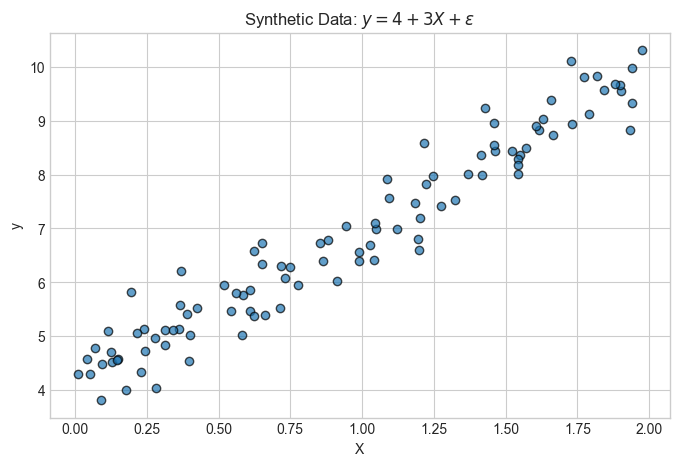

In [5]:
# Generate synthetic data
np.random.seed(42)
m = 100  # number of samples
X = 2 * np.random.rand(m)  # feature
y = 4 + 3 * X + np.random.randn(m) * 0.5  # true relation: y = 4 + 3x + noise

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7, edgecolors="k")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data: $y = 4 + 3X + \\epsilon$")
plt.show()

### 5.1 Cost Function (Mean Squared Error)

$$J(\theta_0, \theta_1) = \frac{1}{2m} \sum_{i=1}^{m} (\theta_0 + \theta_1 x^{(i)} - y^{(i)})^2$$

In [6]:
def compute_cost(X, y, theta0, theta1):
    """Compute the MSE cost for linear regression"""
    m = len(y)
    predictions = theta0 + theta1 * X
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost


def compute_gradients(X, y, theta0, theta1):
    """Compute partial derivatives of cost w.r.t. theta0 and theta1"""
    m = len(y)
    predictions = theta0 + theta1 * X
    error = predictions - y

    d_theta0 = (1 / m) * np.sum(error)
    d_theta1 = (1 / m) * np.sum(error * X)

    return d_theta0, d_theta1

### 5.2 Implementing the Gradient Descent Loop

In [7]:
def gradient_descent_linear(X, y, learning_rate=0.1, n_iterations=100):
    """Gradient descent for simple linear regression (y = theta0 + theta1 * x)"""
    # Initialize parameters randomly
    theta0 = np.random.randn()
    theta1 = np.random.randn()

    cost_history = []
    theta_history = [(theta0, theta1)]

    for i in range(n_iterations):
        # Step 1: Compute gradients
        d_theta0, d_theta1 = compute_gradients(X, y, theta0, theta1)

        # Step 2: Update parameters
        theta0 = theta0 - learning_rate * d_theta0
        theta1 = theta1 - learning_rate * d_theta1

        # Record history
        cost = compute_cost(X, y, theta0, theta1)
        cost_history.append(cost)
        theta_history.append((theta0, theta1))

    return theta0, theta1, cost_history, theta_history


# Run gradient descent
np.random.seed(0)
theta0, theta1, cost_history, theta_history = gradient_descent_linear(
    X, y, learning_rate=0.1, n_iterations=200
)

print(f"Learned parameters:")
print(f"  theta0 (intercept) = {theta0:.4f}  (true: 4.0)")
print(f"  theta1 (slope)     = {theta1:.4f}  (true: 3.0)")
print(f"  Final cost         = {cost_history[-1]:.6f}")

Learned parameters:
  theta0 (intercept) = 4.1048  (true: 4.0)
  theta1 (slope)     = 2.8875  (true: 3.0)
  Final cost         = 0.100824


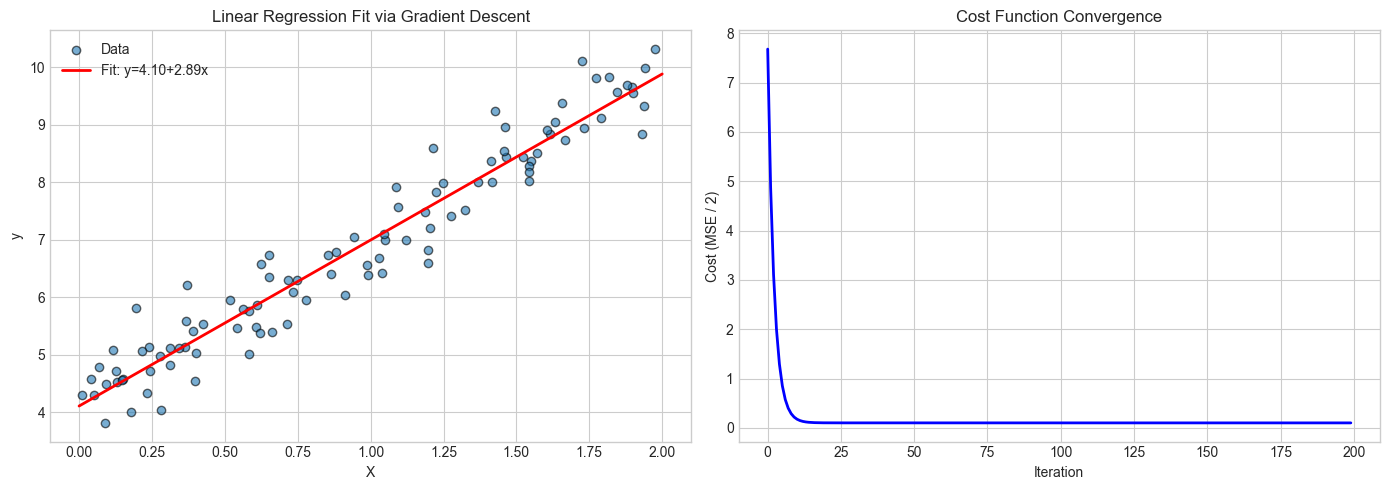

In [8]:
# Visualize the fit and convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Data + fitted line
axes[0].scatter(X, y, alpha=0.6, edgecolors="k", label="Data")
x_line = np.linspace(0, 2, 100)
axes[0].plot(
    x_line,
    theta0 + theta1 * x_line,
    "r-",
    linewidth=2,
    label=f"Fit: y={theta0:.2f}+{theta1:.2f}x",
)
axes[0].set_xlabel("X")
axes[0].set_ylabel("y")
axes[0].set_title("Linear Regression Fit via Gradient Descent")
axes[0].legend()

# Right: Cost over iterations
axes[1].plot(cost_history, "b-", linewidth=2)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Cost (MSE / 2)")
axes[1].set_title("Cost Function Convergence")

plt.tight_layout()
plt.show()

---
## 6. Visualizing the Cost Surface (3D)

The cost function $ J(\theta_0, \theta_1) $ defines a **surface** in 3D space. Gradient descent walks along this surface from a starting point down to the minimum.

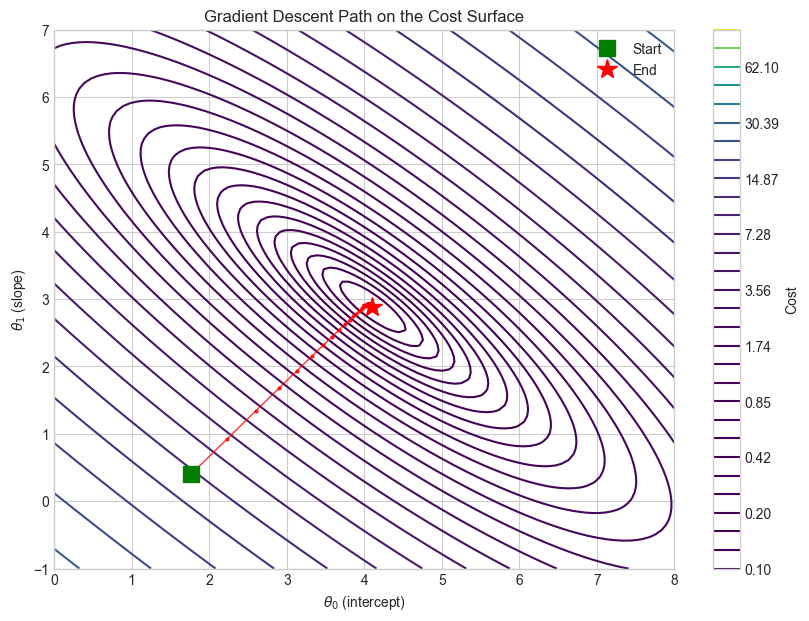

In [9]:
# Create a grid of theta0 and theta1 values
theta0_range = np.linspace(0, 8, 100)
theta1_range = np.linspace(-1, 7, 100)
T0, T1 = np.meshgrid(theta0_range, theta1_range)

# Compute cost at each point
Cost = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        Cost[i, j] = compute_cost(X, y, T0[i, j], T1[i, j])

# Plot contour + gradient descent path
plt.figure(figsize=(10, 7))
plt.contour(T0, T1, Cost, levels=np.logspace(-1, 2, 30), cmap="viridis")
plt.colorbar(label="Cost")

# Plot the path of gradient descent
th = np.array(theta_history)
plt.plot(th[:, 0], th[:, 1], "r.-", markersize=4, linewidth=1, alpha=0.8)
plt.plot(th[0, 0], th[0, 1], "gs", markersize=12, label="Start")
plt.plot(th[-1, 0], th[-1, 1], "r*", markersize=15, label="End")

plt.xlabel("$\\theta_0$ (intercept)")
plt.ylabel("$\\theta_1$ (slope)")
plt.title("Gradient Descent Path on the Cost Surface")
plt.legend()
plt.show()

The contour lines represent levels of equal cost. Gradient descent follows a path **perpendicular to the contour lines**, heading toward the center (minimum cost).

---
## 7. Watching the Line Fit Evolve

Let's visualize how the regression line changes at different stages of gradient descent:

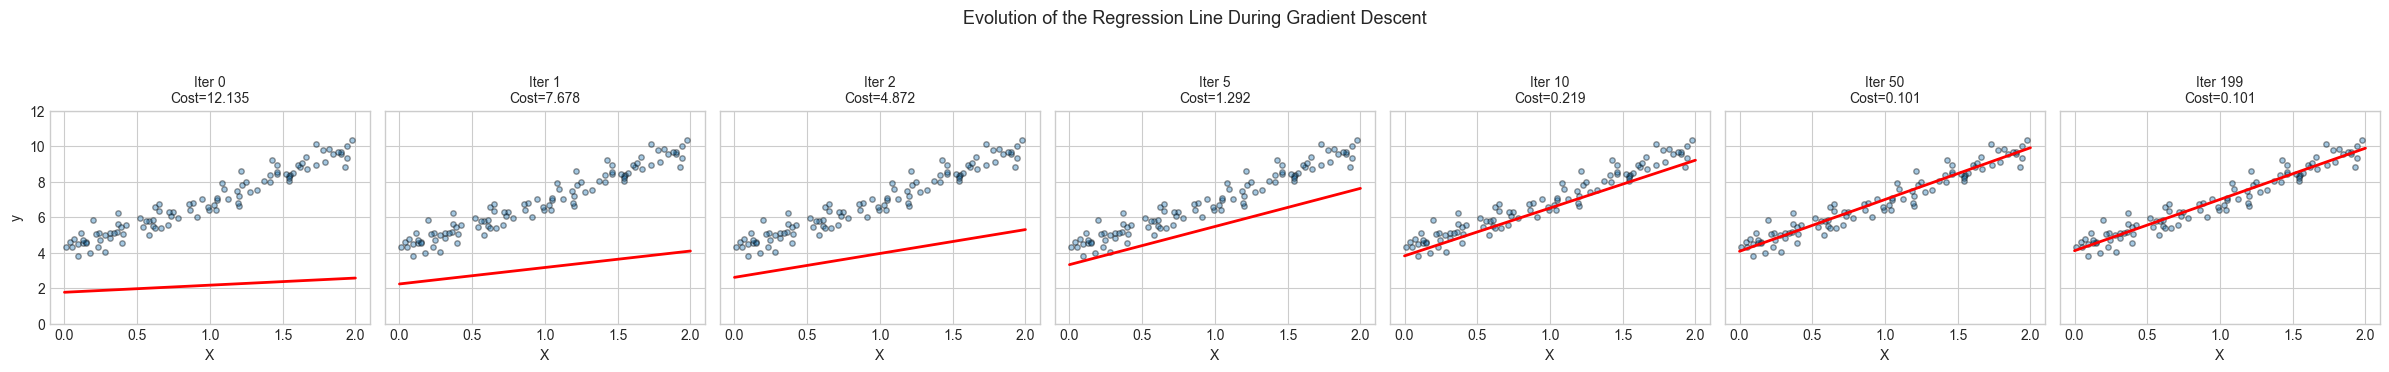

In [10]:
# Show the fit at selected iterations
iterations_to_show = [0, 1, 2, 5, 10, 50, 199]

fig, axes = plt.subplots(1, len(iterations_to_show), figsize=(24, 3.5), sharey=True)

for idx, it in enumerate(iterations_to_show):
    t0, t1 = theta_history[it]
    cost = compute_cost(X, y, t0, t1)

    axes[idx].scatter(X, y, alpha=0.4, s=15, edgecolors="k")
    x_line = np.linspace(0, 2, 50)
    axes[idx].plot(x_line, t0 + t1 * x_line, "r-", linewidth=2)
    axes[idx].set_title(f"Iter {it}\nCost={cost:.3f}", fontsize=10)
    axes[idx].set_xlabel("X")
    axes[idx].set_ylim(0, 12)

axes[0].set_ylabel("y")
fig.suptitle(
    "Evolution of the Regression Line During Gradient Descent", fontsize=13, y=1.05
)
plt.tight_layout()
plt.show()

---
## 8. Feature Scaling — Why It Matters

When features have **very different scales**, the cost surface becomes elongated (elliptical contours). This causes gradient descent to **zig-zag** and converge slowly.

**Feature scaling** (e.g., standardization) makes contours more circular, leading to faster convergence.

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

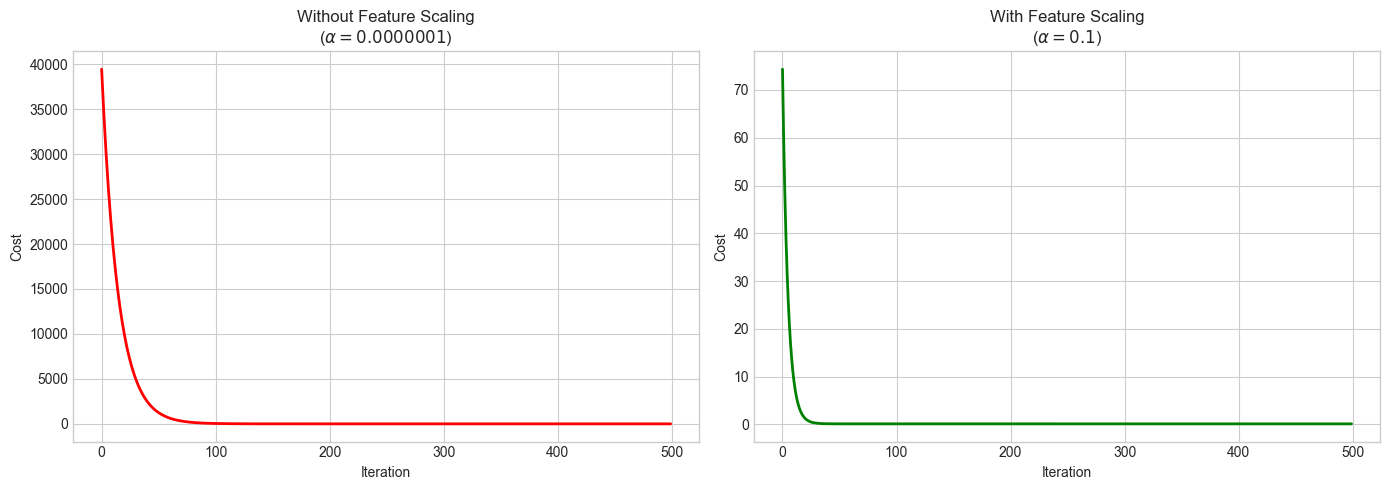

Without scaling — Final cost: 5.0831
With scaling    — Final cost: 0.1210


In [11]:
# Demonstrate with a 2-feature example
np.random.seed(42)
m = 200

# Feature 1: small scale (0-1), Feature 2: large scale (0-1000)
X_multi = np.column_stack(
    [
        np.random.rand(m),  # Feature 1
        np.random.rand(m) * 1000,  # Feature 2
    ]
)
y_multi = 5 + 2 * X_multi[:, 0] + 0.01 * X_multi[:, 1] + np.random.randn(m) * 0.5


def gradient_descent_multi(X, y, learning_rate, n_iterations):
    """Gradient descent for multiple linear regression with intercept"""
    m, n = X.shape
    # Add bias column
    X_b = np.column_stack([np.ones(m), X])
    theta = np.random.randn(n + 1)
    cost_history = []

    for _ in range(n_iterations):
        predictions = X_b @ theta
        error = predictions - y
        gradients = (1 / m) * X_b.T @ error
        theta = theta - learning_rate * gradients
        cost = (1 / (2 * m)) * np.sum(error**2)
        cost_history.append(cost)

    return theta, cost_history


# Without scaling
_, cost_no_scale = gradient_descent_multi(
    X_multi, y_multi, learning_rate=0.0000001, n_iterations=500
)

# With scaling
X_scaled = (X_multi - X_multi.mean(axis=0)) / X_multi.std(axis=0)
_, cost_scaled = gradient_descent_multi(
    X_scaled, y_multi, learning_rate=0.1, n_iterations=500
)

# Compare convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cost_no_scale, "r-", linewidth=2)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Cost")
axes[0].set_title("Without Feature Scaling\n($\\alpha = 0.0000001$)")

axes[1].plot(cost_scaled, "g-", linewidth=2)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Cost")
axes[1].set_title("With Feature Scaling\n($\\alpha = 0.1$)")

plt.tight_layout()
plt.show()

print(f"Without scaling — Final cost: {cost_no_scale[-1]:.4f}")
print(f"With scaling    — Final cost: {cost_scaled[-1]:.4f}")

**Key insight**: Feature scaling allows using a larger learning rate and reaches convergence much faster.

---
## 9. Variants of Gradient Descent

So far we used **Batch Gradient Descent** — computing gradients using **all** training examples. There are two other important variants:

| Variant | Samples per Update | Pros | Cons |
|---|---|---|---|
| **Batch GD** | All $ m $ samples | Stable, smooth convergence | Slow for large datasets |
| **Stochastic GD (SGD)** | 1 sample | Fast updates, can escape local minima | Noisy, unstable |
| **Mini-Batch GD** | $ b $ samples (e.g., 32) | Good balance of speed & stability | Requires batch size tuning |

In [12]:
def batch_gradient_descent(X, y, lr=0.1, n_iter=100):
    """Standard Batch Gradient Descent"""
    m = len(y)
    theta0, theta1 = np.random.randn(), np.random.randn()
    costs = []
    for _ in range(n_iter):
        pred = theta0 + theta1 * X
        error = pred - y
        theta0 -= lr * (1 / m) * np.sum(error)
        theta1 -= lr * (1 / m) * np.sum(error * X)
        costs.append(compute_cost(X, y, theta0, theta1))
    return theta0, theta1, costs


def stochastic_gradient_descent(X, y, lr=0.01, n_epochs=50):
    """Stochastic Gradient Descent — 1 sample at a time"""
    m = len(y)
    theta0, theta1 = np.random.randn(), np.random.randn()
    costs = []
    for epoch in range(n_epochs):
        indices = np.random.permutation(m)  # shuffle data each epoch
        for i in indices:
            pred = theta0 + theta1 * X[i]
            error = pred - y[i]
            theta0 -= lr * error
            theta1 -= lr * error * X[i]
        costs.append(compute_cost(X, y, theta0, theta1))
    return theta0, theta1, costs


def mini_batch_gradient_descent(X, y, lr=0.05, n_epochs=50, batch_size=16):
    """Mini-Batch Gradient Descent"""
    m = len(y)
    theta0, theta1 = np.random.randn(), np.random.randn()
    costs = []
    for epoch in range(n_epochs):
        indices = np.random.permutation(m)
        for start in range(0, m, batch_size):
            batch_idx = indices[start : start + batch_size]
            X_batch, y_batch = X[batch_idx], y[batch_idx]
            b = len(X_batch)
            pred = theta0 + theta1 * X_batch
            error = pred - y_batch
            theta0 -= lr * (1 / b) * np.sum(error)
            theta1 -= lr * (1 / b) * np.sum(error * X_batch)
        costs.append(compute_cost(X, y, theta0, theta1))
    return theta0, theta1, costs

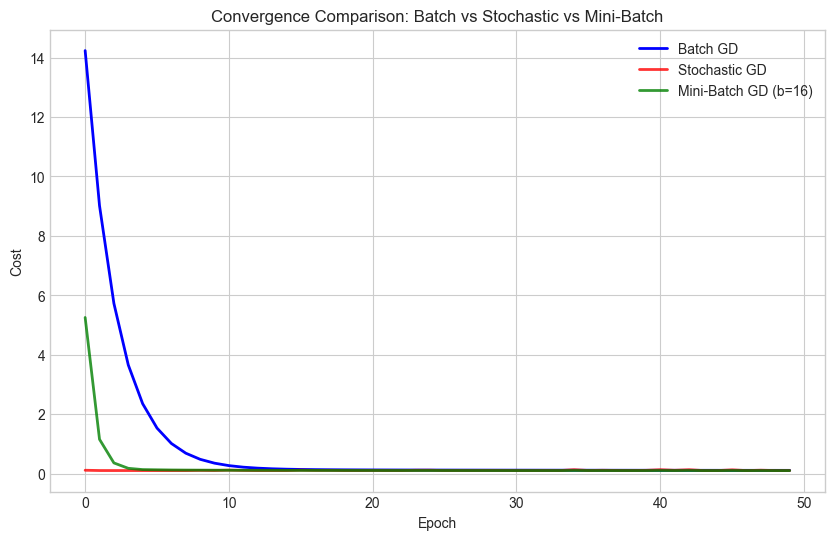

In [13]:
# Compare the three variants
np.random.seed(42)
_, _, costs_batch = batch_gradient_descent(X, y, lr=0.1, n_iter=50)

np.random.seed(42)
_, _, costs_sgd = stochastic_gradient_descent(X, y, lr=0.05, n_epochs=50)

np.random.seed(42)
_, _, costs_mini = mini_batch_gradient_descent(
    X, y, lr=0.05, n_epochs=50, batch_size=16
)

plt.figure(figsize=(10, 6))
plt.plot(costs_batch, "b-", linewidth=2, label="Batch GD")
plt.plot(costs_sgd, "r-", linewidth=2, alpha=0.8, label="Stochastic GD")
plt.plot(costs_mini, "g-", linewidth=2, alpha=0.8, label="Mini-Batch GD (b=16)")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Convergence Comparison: Batch vs Stochastic vs Mini-Batch")
plt.legend()
plt.show()

**Observations**:
- **Batch GD** has the smoothest curve — it sees all data every step
- **SGD** is noisy — each update uses only one sample, so the direction is noisy
- **Mini-Batch GD** is a practical compromise — less noisy than SGD but faster per epoch than batch

---
## 10. Local Minima vs. Global Minima

For **convex** cost functions (like MSE in linear regression), there is only **one minimum** — the global minimum. Gradient descent is guaranteed to find it.

For **non-convex** functions, there can be many local minima. Gradient descent might get stuck in one.

Let's visualize this:

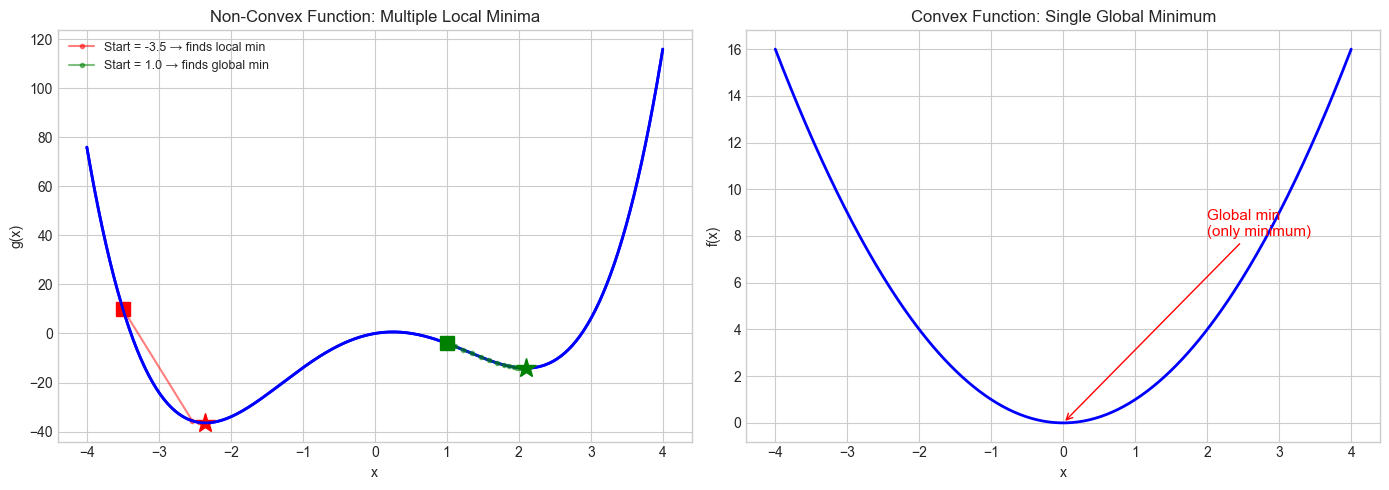

In [14]:
# A non-convex function with multiple local minima
def g(x):
    return x**4 - 10 * x**2 + 5 * x


def dg(x):
    return 4 * x**3 - 20 * x + 5


def gd_custom(start, deriv_func, lr=0.01, n_iter=200):
    x = start
    history = [x]
    for _ in range(n_iter):
        x = x - lr * deriv_func(x)
        history.append(x)
    return np.array(history)


x_range = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

starts = [-3.5, 1.0]
colors = ["red", "green"]
labels = ["Start = -3.5 → finds local min", "Start = 1.0 → finds global min"]

for start, color, label in zip(starts, colors, labels):
    hist = gd_custom(start, dg, lr=0.01, n_iter=300)
    axes[0].plot(x_range, g(x_range), "b-", linewidth=2)
    axes[0].plot(hist, g(hist), f"{color[0]}o-", markersize=3, alpha=0.5, label=label)
    axes[0].plot(hist[0], g(hist[0]), f"{color[0]}s", markersize=10)
    axes[0].plot(hist[-1], g(hist[-1]), f"{color[0]}*", markersize=15)

axes[0].set_xlabel("x")
axes[0].set_ylabel("g(x)")
axes[0].set_title("Non-Convex Function: Multiple Local Minima")
axes[0].legend(fontsize=9)

# Convex function for comparison
axes[1].plot(x_range, x_range**2, "b-", linewidth=2)
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")
axes[1].set_title("Convex Function: Single Global Minimum")
axes[1].annotate(
    "Global min\n(only minimum)",
    xy=(0, 0),
    xytext=(2, 8),
    fontsize=11,
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red",
)

plt.tight_layout()
plt.show()

**Good news**: Linear regression and logistic regression have **convex** cost functions, so gradient descent will always find the global minimum (given a proper learning rate).

---
## 11. Convergence Criteria

How do we know when to **stop**? Common stopping criteria:

1. **Maximum iterations**: Stop after $ N $ iterations
2. **Cost threshold**: Stop when $ J(\theta) < \epsilon $
3. **Gradient threshold**: Stop when $ |\nabla J| < \epsilon $ (gradient near zero)
4. **Cost change threshold**: Stop when $ |J_{t} - J_{t-1}| < \epsilon $ (improvement is negligible)

Converged at iteration 77!
theta0 = 4.1070, theta1 = 2.8856
Total iterations: 77


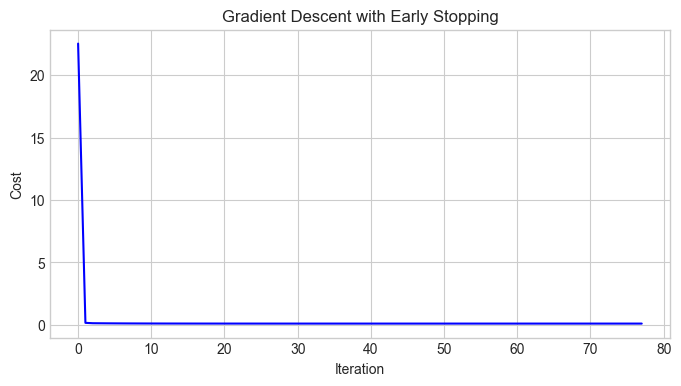

In [15]:
def gradient_descent_with_convergence(X, y, lr=0.1, max_iter=10000, tol=1e-7):
    """Gradient descent with early stopping based on cost improvement"""
    m = len(y)
    theta0, theta1 = np.random.randn(), np.random.randn()
    costs = [compute_cost(X, y, theta0, theta1)]

    for i in range(max_iter):
        d_theta0, d_theta1 = compute_gradients(X, y, theta0, theta1)
        theta0 -= lr * d_theta0
        theta1 -= lr * d_theta1

        cost = compute_cost(X, y, theta0, theta1)
        costs.append(cost)

        # Check convergence: if cost barely changed, stop
        if abs(costs[-2] - costs[-1]) < tol:
            print(f"Converged at iteration {i + 1}!")
            break
    else:
        print(f"Did not converge within {max_iter} iterations.")

    return theta0, theta1, costs


np.random.seed(42)
theta0, theta1, costs = gradient_descent_with_convergence(X, y, lr=0.5, tol=1e-8)
print(f"theta0 = {theta0:.4f}, theta1 = {theta1:.4f}")
print(f"Total iterations: {len(costs) - 1}")

plt.figure(figsize=(8, 4))
plt.plot(costs, "b-")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Gradient Descent with Early Stopping")
plt.show()

---
## 12. Gradient Descent vs. Normal Equation

For linear regression, there's an alternative: the **Normal Equation** which gives a closed-form solution:

$$\theta = (X^T X)^{-1} X^T y$$

| | Gradient Descent | Normal Equation |
|---|---|---|
| Need to choose $ \alpha $ | Yes | No |
| Iterative | Yes | No |
| Works with large $ n $ | Yes (scales well) | Slow (matrix inversion is $ O(n^3) $) |
| Feature scaling needed | Yes | No |
| Works for all models | Yes (general purpose) | Only for linear regression |

**Rule of thumb**: Use the Normal Equation when $ n $ (features) $ < 10{,}000 $. Use gradient descent for larger problems.

In [16]:
# Compare: Gradient Descent vs Normal Equation

# Normal Equation
X_b = np.column_stack([np.ones(len(X)), X])  # add bias
theta_normal = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

print("=== Comparison ===")
print(
    f"Normal Equation:   theta0 = {theta_normal[0]:.4f}, theta1 = {theta_normal[1]:.4f}"
)
print(f"Gradient Descent:  theta0 = {theta0:.4f}, theta1 = {theta1:.4f}")
print(f"True values:       theta0 = 4.0000, theta1 = 3.0000")

=== Comparison ===
Normal Equation:   theta0 = 4.1075, theta1 = 2.8851
Gradient Descent:  theta0 = 4.1070, theta1 = 2.8856
True values:       theta0 = 4.0000, theta1 = 3.0000


Both methods arrive at essentially the same parameters.

---
## 13. Summary

### What We Learned

| Concept | Key Idea |
|---|---|
| **Gradient** | The slope/direction of steepest ascent |
| **Gradient Descent** | Iteratively move opposite to the gradient to minimize cost |
| **Learning Rate** | Controls step size — too small is slow, too large diverges |
| **Feature Scaling** | Normalizing features speeds up convergence |
| **Batch GD** | Uses all data per step — smooth but slow for big data |
| **SGD** | Uses 1 sample per step — fast but noisy |
| **Mini-Batch GD** | Uses small batches — practical compromise |
| **Convexity** | Convex cost → guaranteed global min; non-convex → may get stuck |
| **Convergence** | Stop when cost change is below a tolerance |

### The Gradient Descent Algorithm

```
Initialize parameters θ randomly
Repeat until convergence:
    1. Compute predictions: ŷ = f(X; θ)
    2. Compute cost: J(θ)
    3. Compute gradients: ∇J(θ)
    4. Update parameters: θ = θ - α · ∇J(θ)
```

Gradient descent is the backbone of training most machine learning models. Understanding it deeply is essential for debugging, tuning, and building effective models.